In [ ]:
"""
.py for the application of unsupervised analysis methods on the 

data of the raman spectra after it as been --preprocessed--

"""


#imports for ML
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#imports for lazy predict 
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split

#imports for cross validation
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier

#imports for the preprocessing pipeline
import copy
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from pybaselines.whittaker import drpls
import ramanspy as rp
import matplotlib.pyplot as plt

#imports for the unsupervised methods
from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

"""
Handeling of the dataset

"""

# Load Excel file, no header row, commas as decimal points
file_path = "C:\\Users\\UTILIZADOR\\Desktop\\Projeto\\Envi\\raw_feat.xlsx"
df = pd.read_excel(file_path, header=None, decimal=',')

# Step 1: Extract wavenumbers from first row, skip column A, exclude last 3 metadata columns
wavenumbers = df.iloc[0, 1:-3].astype(float).values

# Step 2: Extract intensity data (all rows except first, skip column A, exclude metadata)
intensity_data = df.iloc[1:, 1:-3].astype(float).values

# Step 3: Extract metadata (from last 3 columns)
labels = df.iloc[1:, -3].values
concentrations = df.iloc[1:, -2].values
names = df.iloc[1:, -1].values

# Step 4: Build list of spectra
raman_spectra = []
metadata = []

for i in range(intensity_data.shape[0]):
    y_array = intensity_data[i, :]
    spectrum = [wavenumbers, y_array]
    raman_spectra.append(spectrum)
    metadata.append({
        'label': labels[i],
        'concentration': concentrations[i],
        'name': names[i]
    })


"""
Pre-processing of the raman spectra

"""

def cropper(raman_spectrum, *intervals):
    x = np.array(raman_spectrum[0])
    y = np.array(raman_spectrum[1])

    for interval in intervals:
        min_value, max_value = interval
        indices_to_keep = np.where((x >= min_value) & (x <= max_value))
        x = x[indices_to_keep]
        y = y[indices_to_keep]

    return [x, y]


def whitaker_hayes(raman_spectrum, threshold=6):  #threshold=8
        y_array = raman_spectrum[1]
        median_y = np.median(y_array)
        std_y = np.std(y_array)
        cosmic_rays = np.abs(y_array - median_y) > threshold * std_y
        x_array = raman_spectrum[0]
        x_cosmic = x_array[cosmic_rays]
        f_interp = interp1d(x_array[~cosmic_rays], y_array[~cosmic_rays], kind='quadratic', fill_value='extrapolate') # kind='quadratic'
        y_array[cosmic_rays] = f_interp(x_cosmic)
        return np.array([x_array, y_array])


def denoise_spectrum(raman_spectrum, window_size=15, poly_order=2):# window_size=15, poly_order=2 
        x_array = raman_spectrum[0]
        y_array = raman_spectrum[1]
        window_size = window_size + 1 if window_size % 2 == 0 else window_size
        denoised_y = savgol_filter(y_array, window_size, poly_order)
        return np.array([x_array, denoised_y])


def DRPLS(raman_spectrum, smoothing):
        x_array, y_array = raman_spectrum
        baseline_tuple = drpls(y_array, lam=smoothing, diff_order=2, max_iter=500, tol=0.001, weights=None, x_data=x_array, eta=1.00) #diff_order=2 eta=1.0
        baseline_subtracted_y = y_array - baseline_tuple[0]
        return np.array([x_array, baseline_tuple[0]]), np.array([x_array, baseline_subtracted_y])


def cof_normalize(raman_spectrum): # 1405, 1735
        max_y = None
        for x, y in zip(raman_spectrum[0], raman_spectrum[1]):
            if 1590 <= x <= 1610:
                if max_y is None or y > max_y:
                    max_y = y
        raman_data = raman_spectrum[1] / max_y
        return np.array([raman_spectrum[0], raman_data])



"""
Application of the prepro pipeline

"""

processed_spectra = []

# Process all spectra in a loop
for spectrum in raman_spectra:
    lis_spectrum = tuple(arr.tolist() for arr in spectrum)
    original_spectrum = copy.deepcopy(lis_spectrum)

    # Step 1: Crop
    data_crop = cropper(copy.deepcopy(original_spectrum), (300, 2000))

    # Step 2: Cosmic Ray Removal
    data_hay = whitaker_hayes(copy.deepcopy(data_crop))

    # Step 3: Smoothing
    data_den = denoise_spectrum(copy.deepcopy(data_hay))

    # Step 4: Baseline Correction
    _, data_DRP = DRPLS(copy.deepcopy(data_den), 10000)

    # Step 5: Normalization
    data_norm = cof_normalize(copy.deepcopy(data_DRP))

    # Step 6: Final Crop and Sort
    data_crop_f = cropper(copy.deepcopy(data_norm), (400, 2000))
   

    processed_spectra.append(copy.deepcopy(data_crop_f))


ready_processed_spectra = np.array([spectrum[1] for spectrum in processed_spectra])



"""
Lazy predict apllication on the data - benchmark many machine learning models (classifiers or regressors) with minimal code.
It trains multiple models on your data and reports their performance side-by-side — great for initial model selection.

"""

# Extract labels
y = np.array([meta['label'] for meta in metadata])

"""
Processed scpectra
"""

X_processed = ready_processed_spectra

# Split into train/test
X_train_processed, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=99, stratify=y
)

# Run LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train_processed, X_test, y_train, y_test)

# Display the results
print(models)


"""
Stratified Cross-validation for pre processed spectra

"""
# Stratified cross-validation scheme
stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

# Models
models = {
    "RandomForest_prepro": RandomForestClassifier(random_state=99),
    "LGBM_prepro": LGBMClassifier(random_state=99),
    "ExtraTrees_prepro": ExtraTreesClassifier(random_state=99),
}

# Perform Stratified 5-fold cross-validation for each model
for name, model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=stratified_kf, scoring='accuracy')  # or 'f1_macro'
    print(f"{name} - Stratified Accuracy average: {scores.mean():.4f} (+/- {scores.std():.4f})")


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019765 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 106965
[LightGBM] [Info] Number of data points in the train set: 583, number of used features: 550
[LightGBM] [Info] Start training from score -1.580695
[LightGBM] [Info] Start training from score -1.614597
[LightGBM] [Info] Start training from score -1.614597
[LightGBM] [Info] Start training from score -1.580695
[LightGBM] [Info] Start training from score -1.658657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 85583
[LightGBM] [Info] Number of data points in the train set: 466, number of used features: 550
[LightGBM] [Info] Start training from score -1.579837
[LightGBM] [Info] Start training from score -1.611586
[LightGBM] [Info] Start training from score -1.611586
[LightGBM] [Info] Start training from score -1.579837
[LightGBM] [Info] Start training from score -1.666849
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

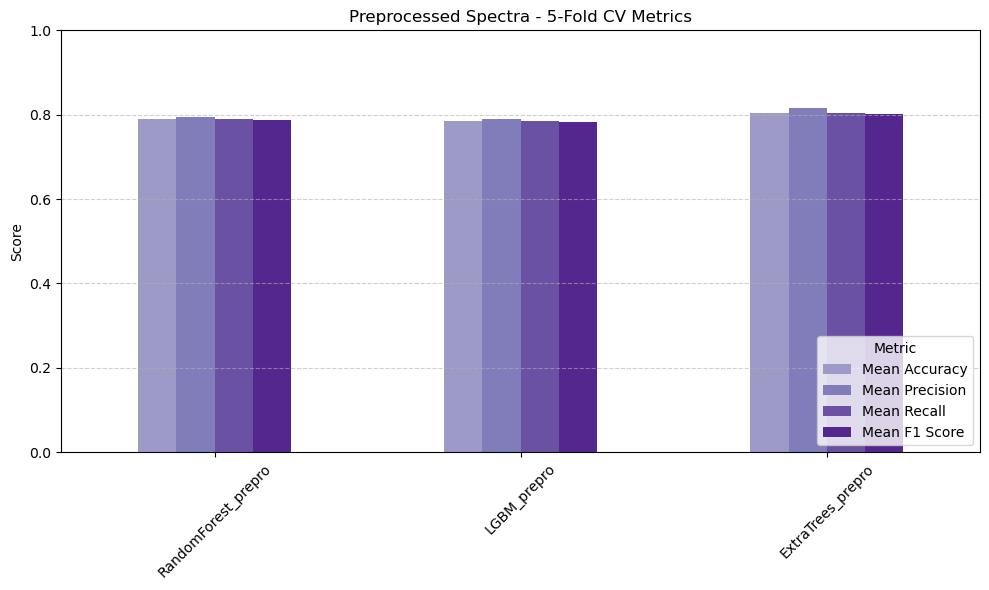

In [ ]:
# Stratified K-Fold
stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

# Models to test
models = {
    "RandomForest": RandomForestClassifier(random_state=99),
    "LGBM": LGBMClassifier(random_state=99),
    "ExtraTrees": ExtraTreesClassifier(random_state=99),
}

# Metrics to compute
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
results = {}

# Evaluate each model with each metric
for name, model in models.items():
    metrics = {}
    for metric in scoring:
        score = cross_val_score(model, X_train_processed, y_train, cv=stratified_kf, scoring=metric)
        metrics[metric] = score.mean()
    results[name] = metrics

# Organize into DataFrame
df_results = pd.DataFrame(results).T
df_results.columns = ['Mean Accuracy', 'Mean Precision', 'Mean Recall', 'Mean F1 Score']

# Plot 
df_results.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#9e9ac8', '#807dba', '#6a51a3', '#54278f']
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Preprocessed Spectra - 5-Fold CV Metrics", fontsize=24)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(loc='lower right', title="Metric")
plt.show()


In [ ]:
# Best model with tuned hyperparameters
best_et = ExtraTreesClassifier(
    max_depth=20,
    max_features='log2',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=99
)

# Cross-validation to confirm performance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
scores = cross_val_score(best_et, X_train_processed, y_train, cv=cv, scoring='accuracy')

print(f"Accuracy per fold: {scores}")
print(f"Final mean accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")



Acurácia por fold: [0.79487179 0.78632479 0.8034188  0.82758621 0.87068966]
Acurácia média final: 0.8166 (+/- 0.0304)


In [ ]:
# Recreate the model with the best parameters from GridSearchCV
final_model = ExtraTreesClassifier(
    max_depth=20,
    max_features='log2',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=99
)

# Train it on the full training data
final_model.fit(X_train_processed, y_train)

ExtraTreesClassifier(max_depth=20, max_features='log2', n_estimators=200,
                     random_state=99)

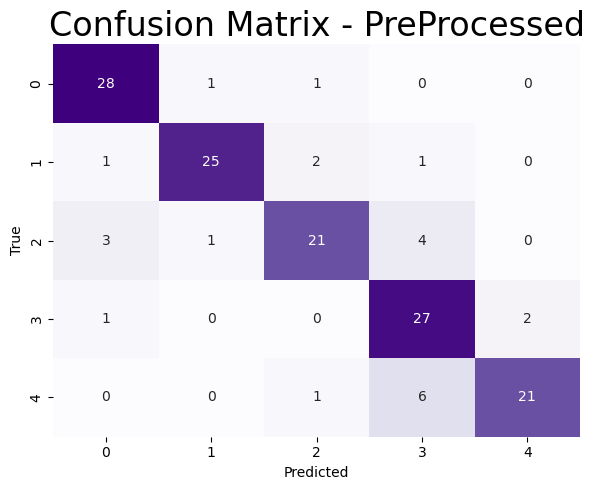

Classification Report:
                  precision    recall  f1-score   support

         control       0.85      0.93      0.89        30
             mix       0.93      0.86      0.89        29
sulfamethoxazole       0.84      0.72      0.78        29
   sulfapyridine       0.71      0.90      0.79        30
   sulfathiazole       0.91      0.75      0.82        28

        accuracy                           0.84       146
       macro avg       0.85      0.83      0.84       146
    weighted avg       0.85      0.84      0.84       146



In [ ]:
# Final evaluation on the 20% held-out test set
y_pred = final_model.predict(X_test)

# Confusion matrix and classification report

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("Confusion Matrix - PreProcessed", fontsize=24)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))
